
# Notebook 03 — NLP TF-IDF + Ridge Regression Baseline

## 0. Configuration

In [ ]:
import os

DATA_MODE = "full"  # debug | experiment | full

DATA_DIR = "../dataset/cleaned"

TRAIN_FILE = os.path.join(DATA_DIR, f"train_clean_{DATA_MODE}.csv")
TEST_FILE  = os.path.join(DATA_DIR, f"test_clean_{DATA_MODE}.csv")

ARTIFACT_DIR = f"../artifacts/notebook_03/{DATA_MODE}"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

print(f"Mode: {DATA_MODE}")
print(f"Train: {TRAIN_FILE}")
print(f"Test:  {TEST_FILE}")


In [ ]:
import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import sparse
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)


VALID_SIZE = 0.20
RANDOM_STATE = 42

WORD_NGRAM_RANGE = (1, 2)
WORD_MIN_DF = 2
WORD_MAX_DF = 0.98
WORD_MAX_FEATURES = 200_000

CHAR_NGRAM_RANGE = (3, 5)
CHAR_MIN_DF = 2
CHAR_MAX_DF = 0.995
CHAR_MAX_FEATURES = 150_000

RIDGE_ALPHA = 10.0
USE_LOG_TARGET = True
PREDICTION_MIN = 1e-6

print("Configuration loaded.")


Configuration loaded.


## 1. Load cleaned datasets

In [2]:

train = pd.read_csv(TRAIN_FILE)
test = pd.read_csv(TEST_FILE)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

display(train.head(3))


Train shape: (193693, 27)
Test shape : (50000, 26)


,PRODUCT_ID,TITLE,BULLET_POINTS,DESCRIPTION,PRODUCT_TYPE_ID,PRODUCT_LENGTH,DIM_1_CM,DIM_2_CM,DIM_3_CM,DIM_COUNT,DIM_PRODUCT_2D_CM2,DIM_VOLUME_CM3,HAS_DIMENSION_2D,HAS_DIMENSION_3D,TITLE_CHAR_COUNT,TITLE_WORD_COUNT,TITLE_DIGIT_COUNT,TITLE_EMPTY,BULLET_CHAR_COUNT,BULLET_WORD_COUNT,BULLET_DIGIT_COUNT,BULLET_EMPTY,DESC_CHAR_COUNT,DESC_WORD_COUNT,DESC_DIGIT_COUNT,DESC_EMPTY,HAS_MEASUREMENT_UNIT
0,667259,Work-Life Balance and Women's Entrepreneurship: An Exploration of Influencing Factors (Contribut...,NaN,NaN,6046,614.000000,15.7,21.0,8.509,0,329.7,2805.4173,0,0,123,14,0,0,0,0,0,1,0,0,0,1,0
1,2519657,YES2GOOD Back Case Cover for Oppo K3 Smoke Cover Protective Shockproof Translucent Hybrid Matte ...,[[Matte Translucent Case]: Made by high quality translucent matte non-glossy hard back and soft ...,YES2GOOD Matte Finish Shockproof Hard Back and Side Soft Smoke Back Case Cover can be easily ins...,12064,787.401574,1.0,3.0,17.800,0,3.0,53.4000,0,0,155,23,2,0,862,133,0,0,629,98,1,0,1
2,2169829,"Lettre ouverte du golfe de gascogne : Quelques propos insolites sur la société, la culture et la...",NaN,NaN,1,590.551180,6.0,11.0,2.500,0,66.0,165.0000,0,0,112,20,0,0,0,0,0,1,0,0,0,1,0


## 2. Validate Notebook 02 output

In [3]:

required_train = [
    "PRODUCT_ID", "TITLE", "BULLET_POINTS",
    "DESCRIPTION", "PRODUCT_TYPE_ID", "PRODUCT_LENGTH"
]

required_test = [
    "PRODUCT_ID", "TITLE", "BULLET_POINTS",
    "DESCRIPTION", "PRODUCT_TYPE_ID"
]

for col in required_train:
    assert col in train.columns, f"Missing train column: {col}"

for col in required_test:
    assert col in test.columns, f"Missing test column: {col}"

assert "PRODUCT_LENGTH" not in test.columns
assert train["PRODUCT_ID"].is_unique
assert test["PRODUCT_ID"].is_unique
assert train["PRODUCT_LENGTH"].notna().all()
assert np.isfinite(train["PRODUCT_LENGTH"]).all()
assert (train["PRODUCT_LENGTH"] > 0).all()

print("Clean-data validation PASSED.")
display(train["PRODUCT_LENGTH"].describe())


Clean-data validation PASSED.


count    193693.000000
mean       1013.605130
std        1184.181327
min          56.692800
25%         531.495000
50%         669.291338
75%        1050.000000
max        9500.000000
Name: PRODUCT_LENGTH, dtype: float64

## 3. Build NLP text

In [4]:

TEXT_COLS = ["TITLE", "BULLET_POINTS", "DESCRIPTION"]

def build_text(df):
    text = (
        df["TITLE"].fillna("").astype(str) + " " +
        df["BULLET_POINTS"].fillna("").astype(str) + " " +
        df["DESCRIPTION"].fillna("").astype(str)
    )
    return text.str.replace(r"\s+", " ", regex=True).str.strip()

train["NLP_TEXT"] = build_text(train)
test["NLP_TEXT"] = build_text(test)

display(train[["TITLE", "NLP_TEXT"]].head(5))


,TITLE,NLP_TEXT
0,Work-Life Balance and Women's Entrepreneurship: An Exploration of Influencing Factors (Contribut...,Work-Life Balance and Women's Entrepreneurship: An Exploration of Influencing Factors (Contribut...
1,YES2GOOD Back Case Cover for Oppo K3 Smoke Cover Protective Shockproof Translucent Hybrid Matte ...,YES2GOOD Back Case Cover for Oppo K3 Smoke Cover Protective Shockproof Translucent Hybrid Matte ...
2,"Lettre ouverte du golfe de gascogne : Quelques propos insolites sur la société, la culture et la...","Lettre ouverte du golfe de gascogne : Quelques propos insolites sur la société, la culture et la..."
3,Jockey Men's Cotton Racer Back Vest (8901326071908_9922_M_Shanghai Red),Jockey Men's Cotton Racer Back Vest (8901326071908_9922_M_Shanghai Red) [Color Name: Shanghai Re...
4,"LIBAS ROYYD Men's Cotton Casual Shirt (Sky Blue, 46)","LIBAS ROYYD Men's Cotton Casual Shirt (Sky Blue, 46) [Fabric type :- 100% fine Giza cotton,Stitc..."


## 4. Train / validation split

In [5]:

indices = np.arange(len(train))

train_idx, valid_idx = train_test_split(
    indices,
    test_size=VALID_SIZE,
    random_state=RANDOM_STATE
)

train_part = train.iloc[train_idx].copy()
valid_part = train.iloc[valid_idx].copy()

print("Training rows  :", len(train_part))
print("Validation rows:", len(valid_part))


Training rows  : 154954
Validation rows: 38739


## 5. Evaluation functions

In [6]:

def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (y_true != 0)

    y_true = y_true[mask]
    y_pred = y_pred[mask]

    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100.0


def evaluate_model(name, y_true, y_pred):
    y_pred = np.maximum(np.asarray(y_pred, dtype=np.float64), PREDICTION_MIN)

    result = {
        "model": name,
        "MAPE": mape(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))
    }

    print(f"\n{name}")
    print("-" * len(name))
    print(f"MAPE : {result['MAPE']:.4f}%")
    print(f"MAE  : {result['MAE']:.4f}")
    print(f"RMSE : {result['RMSE']:.4f}")

    return result, y_pred


## 6. Prepare target

In [7]:

y_train_raw = train_part["PRODUCT_LENGTH"].astype(np.float64).values
y_valid_raw = valid_part["PRODUCT_LENGTH"].astype(np.float64).values

if USE_LOG_TARGET:
    y_train = np.log1p(y_train_raw)
else:
    y_train = y_train_raw

print("Target:", "log1p(PRODUCT_LENGTH)" if USE_LOG_TARGET else "raw PRODUCT_LENGTH")


Target: log1p(PRODUCT_LENGTH)


## 7. Word-level TF-IDF

In [8]:

word_vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=WORD_NGRAM_RANGE,
    min_df=WORD_MIN_DF,
    max_df=WORD_MAX_DF,
    max_features=WORD_MAX_FEATURES,
    sublinear_tf=True,
    lowercase=True,
    strip_accents="unicode",
    dtype=np.float32
)

X_train_word = word_vectorizer.fit_transform(train_part["NLP_TEXT"])
X_valid_word = word_vectorizer.transform(valid_part["NLP_TEXT"])
X_test_word = word_vectorizer.transform(test["NLP_TEXT"])

print("Word TF-IDF")
print("Train:", X_train_word.shape)
print("Valid:", X_valid_word.shape)
print("Test :", X_test_word.shape)
print("Train non-zero values:", X_train_word.nnz)


Word TF-IDF
Train: (154954, 200000)
Valid: (38739, 200000)
Test : (50000, 200000)
Train non-zero values: 19313941


## 8. Ridge + Word TF-IDF

In [9]:

ridge_word = Ridge(alpha=RIDGE_ALPHA, solver="lsqr")
ridge_word.fit(X_train_word, y_train)

pred_word_model = ridge_word.predict(X_valid_word)
pred_word = np.expm1(pred_word_model) if USE_LOG_TARGET else pred_word_model

word_result, pred_word = evaluate_model(
    "Ridge + Word TF-IDF",
    y_valid_raw,
    pred_word
)



Ridge + Word TF-IDF
-------------------
MAPE : 51.2779%
MAE  : 412.7843
RMSE : 947.9734


## 9. Character-level TF-IDF

In [10]:

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=CHAR_NGRAM_RANGE,
    min_df=CHAR_MIN_DF,
    max_df=CHAR_MAX_DF,
    max_features=CHAR_MAX_FEATURES,
    sublinear_tf=True,
    dtype=np.float32
)

X_train_char = char_vectorizer.fit_transform(train_part["NLP_TEXT"])
X_valid_char = char_vectorizer.transform(valid_part["NLP_TEXT"])
X_test_char = char_vectorizer.transform(test["NLP_TEXT"])

print("Character TF-IDF")
print("Train:", X_train_char.shape)
print("Valid:", X_valid_char.shape)
print("Test :", X_test_char.shape)
print("Train non-zero values:", X_train_char.nnz)


Character TF-IDF
Train: (154954, 150000)
Valid: (38739, 150000)
Test : (50000, 150000)
Train non-zero values: 187931855


## 10. Ridge + Character TF-IDF

In [11]:

ridge_char = Ridge(alpha=RIDGE_ALPHA, solver="lsqr")
ridge_char.fit(X_train_char, y_train)

pred_char_model = ridge_char.predict(X_valid_char)
pred_char = np.expm1(pred_char_model) if USE_LOG_TARGET else pred_char_model

char_result, pred_char = evaluate_model(
    "Ridge + Character TF-IDF",
    y_valid_raw,
    pred_char
)



Ridge + Character TF-IDF
------------------------
MAPE : 52.8859%
MAE  : 421.7879
RMSE : 957.8615


## 11. Combine Word + Character TF-IDF

In [12]:

X_train_tfidf = sparse.hstack(
    [X_train_word, X_train_char],
    format="csr"
)

X_valid_tfidf = sparse.hstack(
    [X_valid_word, X_valid_char],
    format="csr"
)

X_test_tfidf = sparse.hstack(
    [X_test_word, X_test_char],
    format="csr"
)

print("Combined TF-IDF")
print("Train:", X_train_tfidf.shape)
print("Valid:", X_valid_tfidf.shape)
print("Test :", X_test_tfidf.shape)


Combined TF-IDF
Train: (154954, 350000)
Valid: (38739, 350000)
Test : (50000, 350000)


## 12. Ridge + Combined TF-IDF

In [13]:

ridge_tfidf = Ridge(alpha=RIDGE_ALPHA, solver="lsqr")
ridge_tfidf.fit(X_train_tfidf, y_train)

pred_tfidf_model = ridge_tfidf.predict(X_valid_tfidf)
pred_tfidf = np.expm1(pred_tfidf_model) if USE_LOG_TARGET else pred_tfidf_model

tfidf_result, pred_tfidf = evaluate_model(
    "Ridge + Word + Character TF-IDF",
    y_valid_raw,
    pred_tfidf
)



Ridge + Word + Character TF-IDF
-------------------------------
MAPE : 50.1209%
MAE  : 400.6657
RMSE : 913.9719


## 13. Compare the three NLP baselines

In [14]:

results = pd.DataFrame([
    word_result,
    char_result,
    tfidf_result
]).sort_values("MAPE").reset_index(drop=True)

display(results)


,model,MAPE,MAE,RMSE
0,Ridge + Word + Character TF-IDF,50.120892,400.665684,913.971911
1,Ridge + Word TF-IDF,51.277945,412.784276,947.973447
2,Ridge + Character TF-IDF,52.885869,421.787879,957.861493


## 14. MAPE by target range

In [15]:

def mape_by_target_range(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.maximum(np.asarray(y_pred), PREDICTION_MIN)

    ranges = [
        ("54-100", 54, 100),
        ("101-200", 101, 200),
        ("201-500", 201, 500),
        ("501-1000", 501, 1000),
        ("1001-2000", 1001, 2000),
        ("2001-5000", 2001, 5000),
        ("5001+", 5001, np.inf)
    ]

    rows = []

    for label, low, high in ranges:
        mask = (y_true >= low) & (y_true <= high)

        if mask.sum() == 0:
            continue

        rows.append({
            "range": label,
            "count": int(mask.sum()),
            "percentage": float(mask.mean() * 100),
            "MAPE": float(mape(y_true[mask], y_pred[mask]))
        })

    return pd.DataFrame(rows)

range_results = mape_by_target_range(y_valid_raw, pred_tfidf)
display(range_results)


,range,count,percentage,MAPE
0,54-100,829,2.139962,559.383178
1,101-200,1281,3.306745,235.678929
2,201-500,6839,17.654044,61.304271
3,501-1000,19854,51.250678,19.237228
4,1001-2000,6992,18.048995,30.681607
5,2001-5000,2013,5.196314,50.994681
6,5001+,927,2.392937,61.316115


## 15. Actual vs predicted

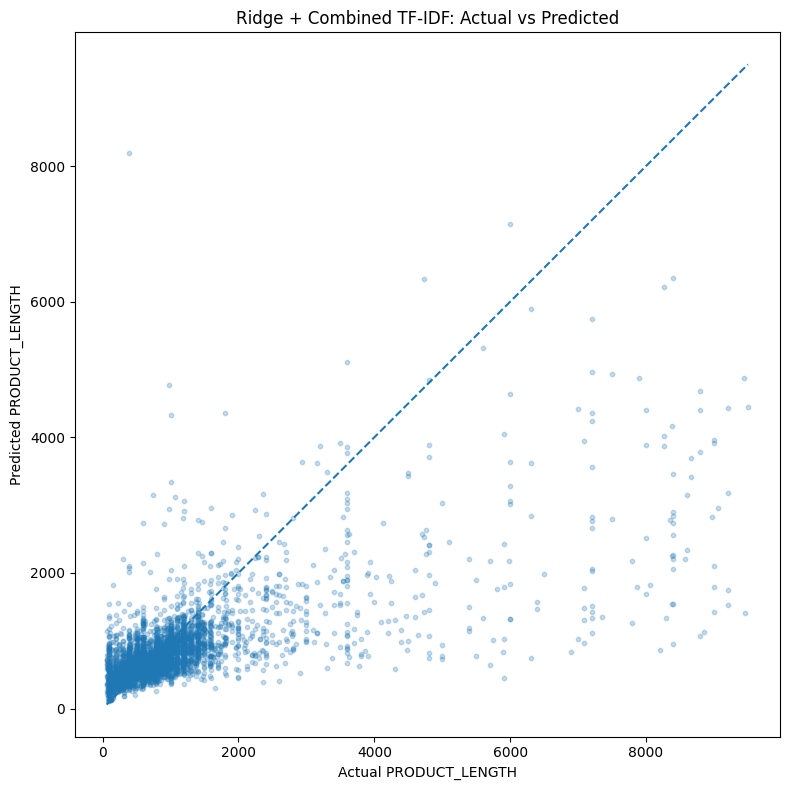

In [16]:

sample_size = min(5000, len(y_valid_raw))
rng = np.random.default_rng(RANDOM_STATE)

sample_idx = rng.choice(
    len(y_valid_raw),
    size=sample_size,
    replace=False
)

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(
    y_valid_raw[sample_idx],
    pred_tfidf[sample_idx],
    alpha=0.25,
    s=10
)

low = min(y_valid_raw[sample_idx].min(), pred_tfidf[sample_idx].min())
high = max(y_valid_raw[sample_idx].max(), pred_tfidf[sample_idx].max())

ax.plot([low, high], [low, high], linestyle="--")

ax.set_xlabel("Actual PRODUCT_LENGTH")
ax.set_ylabel("Predicted PRODUCT_LENGTH")
ax.set_title("Ridge + Combined TF-IDF: Actual vs Predicted")

plt.tight_layout()
plt.show()


## 16. Inspect worst validation errors

In [17]:

error_df = valid_part[
    ["PRODUCT_ID", "TITLE", "PRODUCT_TYPE_ID", "PRODUCT_LENGTH"]
].copy()

error_df["prediction"] = pred_tfidf
error_df["absolute_error"] = (
    np.abs(error_df["PRODUCT_LENGTH"] - error_df["prediction"])
)

error_df["APE"] = (
    error_df["absolute_error"] /
    error_df["PRODUCT_LENGTH"]
) * 100

display(error_df.sort_values("APE", ascending=False).head(50))


,PRODUCT_ID,TITLE,PRODUCT_TYPE_ID,PRODUCT_LENGTH,prediction,absolute_error,APE
111387,2061972,Nuha Rugs Shag Rug Beige and Ivory Color 5 cm Pile Height Modern Shaggy Carpet for Bedroom Home ...,1634,196.850393,7789.177734,7592.327341,3856.902293
74901,1706794,Kokka IRO Lei Nani Double Gauze Pink Fabric,8401,100.000000,3150.475098,3050.475098,3050.475098
35746,1589184,ASOKAM BAZAAR's Red Floral Print Poly Cotton Multicolor AC Dohar/Summer AC Blanket (Single Bed (...,1622,196.850393,5458.690430,5261.840036,2673.014741
72735,1566784,Island Batik Safari Tortoise Shell Grasshopper Fabric,6007,100.000000,2393.515625,2293.515625,2293.515625
127193,1309331,"Deco 79 98444 Rectangular Wooden Wall Panel, 27"" x 54"", Black/White",1555,100.000000,2313.229004,2213.229004,2213.229004
34628,2044746,Round Hanging Mirrors Wall Decor - Vanity Mounted Wall Mirror with Metal Frame for Contemporary ...,1588,100.000000,2160.584961,2060.584961,2060.584961
41105,2409073,"RJ HOME Cotton Single Bed, Foldable, Light Weight Mattress Soft Medium Gadda (Multicolor,1 Sleep...",12345,393.700787,8198.414062,7804.713276,1982.397174
47162,1441792,Buckle-Down DL-6FT-WDY287-W Pet Leash-Inside Out 6-Character Esxpression Blocks Purple/Multi Col...,7213,100.000000,2049.866211,1949.866211,1949.866211
108037,1058996,Blueberry Pet 5/8-inch by 5-Feet Classic Solid Small Basic Nylon Dog Leash Made For Last - Neon ...,7213,80.000000,1627.428833,1547.428833,1934.286041
152321,1577930,"Raised Garden Bed, Vertical Garden, 3 Container Boxes of 15x15x9in, Elevated Planters to Grow Ve...",5725,100.000000,2002.356079,1902.356079,1902.356079


## 17. Save validation predictions

In [18]:

validation_predictions = valid_part[
    ["PRODUCT_ID", "PRODUCT_TYPE_ID", "PRODUCT_LENGTH"]
].copy()

validation_predictions["prediction"] = pred_tfidf
validation_predictions["APE"] = (
    np.abs(
        validation_predictions["PRODUCT_LENGTH"]
        - validation_predictions["prediction"]
    )
    / validation_predictions["PRODUCT_LENGTH"]
) * 100

PREDICTION_FILE = os.path.join(
    ARTIFACT_DIR,
    "validation_predictions_ridge_tfidf.csv"
)

validation_predictions.to_csv(PREDICTION_FILE, index=False)

print("Saved:", PREDICTION_FILE)


Saved: ../artifacts/notebook_03\validation_predictions_ridge_tfidf.csv


## 18. Save models and vectorizers

In [19]:

joblib.dump(
    word_vectorizer,
    os.path.join(ARTIFACT_DIR, "word_tfidf_vectorizer.joblib")
)

joblib.dump(
    char_vectorizer,
    os.path.join(ARTIFACT_DIR, "char_tfidf_vectorizer.joblib")
)

joblib.dump(
    ridge_word,
    os.path.join(ARTIFACT_DIR, "ridge_word_tfidf.joblib")
)

joblib.dump(
    ridge_char,
    os.path.join(ARTIFACT_DIR, "ridge_char_tfidf.joblib")
)

joblib.dump(
    ridge_tfidf,
    os.path.join(ARTIFACT_DIR, "ridge_combined_tfidf.joblib")
)

print("Artifacts saved to:", ARTIFACT_DIR)


Artifacts saved to: ../artifacts/notebook_03


## 19. Save experiment configuration

In [ ]:

config = {
    "train_file": TRAIN_FILE,
    "test_file": TEST_FILE,
    "validation_size": VALID_SIZE,
    "random_state": RANDOM_STATE,
    "use_log_target": USE_LOG_TARGET,
    "word_ngram_range": list(WORD_NGRAM_RANGE),
    "word_min_df": WORD_MIN_DF,
    "word_max_df": WORD_MAX_DF,
    "word_max_features": WORD_MAX_FEATURES,
    "char_ngram_range": list(CHAR_NGRAM_RANGE),
    "char_min_df": CHAR_MIN_DF,
    "char_max_df": CHAR_MAX_DF,
    "char_max_features": CHAR_MAX_FEATURES,
    "ridge_alpha": RIDGE_ALPHA,
    "results": results.to_dict(orient="records")
}

CONFIG_FILE = os.path.join(
    ARTIFACT_DIR,
    f"{DATA_MODE}_config.json"
)

with open(CONFIG_FILE, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("Saved:", CONFIG_FILE)


Saved: ../artifacts/notebook_03\experiment_config.json



# Notebook 03 Complete
